# **Function Approximation**

<hr>

### **Part 5**: Reinforcement Learning from Zero to One

*African Institute for Mathematical Sciences (AIMS), South Africa
5 March, 2026*

**Arnu Pretorius** - Research Scientist, InstaDeep

<!--

# Flow

Sarsa with FA
--(num_episodes, lr):
* (100, 0.001)
* (100, 0.01)
* (1000, 0.01)
* (1000, 0.1)

Off-policy with ER
* Run as is

-->



## **The *continuous* Numberline**

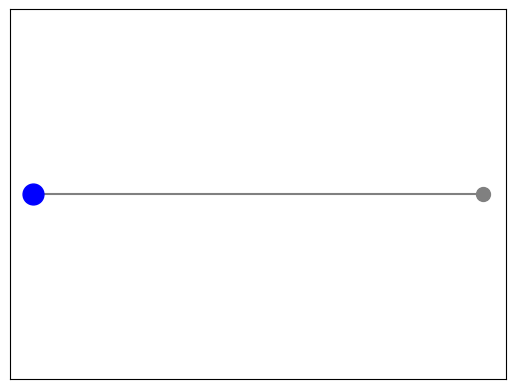

In [1]:
# @title Setup
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# hyperparameters
num_actions = 2
max_steps = 50

class NumberLineEnv:
    def __init__(self, max_steps=50, reward_type='sparse'):
        self.max_steps = max_steps
        self.reward_type = reward_type

    def reset(self, key):
        """Initialize the environment state."""
        state = (0, 0, key)
        timestep = (0, 0, False)
        return state, timestep

    def step(self, state, action):
        """Takes an action in the environment."""
        obs, step_count, key = state
        new_key, sub_key = jax.random.split(key)

        # Determine movement direction (intended or opposite)
        in_obsorbing_goal_state = obs == 1
        obs_shift = jax.random.uniform(sub_key) * 0.25 * action

        # Update position based on stochastic action
        next_obs = jnp.clip(obs+obs_shift, 0, 1)

        # Calculate instantaneous reward
        is_at_goal = next_obs == 1
        reward = jax.lax.cond(
            self.reward_type == 'sparse',
            lambda x: jnp.where(x, 1, 0),
            lambda x: jnp.where(~x, -1, 0),
            is_at_goal,
        )
        done = (jnp.where(step_count == self.max_steps-1, 1, 0) + is_at_goal) > 0
        reward = jnp.where(in_obsorbing_goal_state, 0, reward)

        # Update state
        state = (next_obs, step_count + 1, new_key)
        timestep = (next_obs, reward, done)

        return state, timestep

    def _prepare_figure(self, ax):

        # Add labels and legend
        ax.set_xticks([])
        ax.set_yticks([])

    def _draw_state(self, ax, state):
        obs, _, _ = state
        obs = obs*9

        # Create a line for the state space
        states = range(10)
        ax.plot(states, [0] * len(states), color='gray')

        # Mark agent and target state
        ax.plot(0, 0, 'o', color='gray', markersize=10)
        ax.plot(9, 0, 'o', color='gray', markersize=10)
        color = 'green' if obs == 9 else 'blue'
        ax.plot(obs, 0, 'o', color=color, markersize=15, label='Agent')

    def render(self, state):
        # Prepare figure and axis
        fig, ax = plt.subplots()
        ax.clear()
        self._prepare_figure(ax)

        # Mark the current state of the agent
        self._draw_state(ax, state)
        plt.show()

    def animate(self, states, interval=200, save_path=None):
        fig = plt.figure()
        fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)
        ax = fig.add_subplot(111)
        plt.close(fig)
        self._prepare_figure(ax)

        def make_frame(state) -> None:
            ax.clear()
            self._prepare_figure(ax)
            self._draw_state(ax, state)

        # Create the animation object.
        self._animation = animation.FuncAnimation(
            fig,
            make_frame,
            frames=states,
            interval=interval,
        )

        # Save the animation as a gif.
        if save_path:
            self._animation.save(save_path)

        return self._animation


# policy helper functions
def make_stochastic_policy(burn_key, probs=None):
    if probs is None:
        probs = jnp.array([0.5, 0.5])
    def policy(x, key):
        key, sub_key = jax.random.split(key)
        return jax.random.choice(sub_key, jnp.array([-1, 1]), p=probs)
    return policy


# create environment
env = NumberLineEnv(max_steps=max_steps)
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

# visualise environment
key = jax.random.PRNGKey(3)
env_state, timestep = reset_fn(key)
env.render(env_state)

In [2]:
policy_fn = make_stochastic_policy
policy = policy_fn(jax.random.PRNGKey(0))

In [3]:
from matplotlib import rc
rc('animation', html='jshtml')

def animation_rollout(policy, key):
    # make animation of random policy
    env_state, (obs, _, done) = reset_fn(key)
    env_states = [env_state]
    while not done:
        key, subkey = jax.random.split(key)
        action = policy(obs, subkey)
        env_state, (obs, _, done) = step_fn(env_state, action)
        env_states.append(env_state)
    return env_states

env_states = animation_rollout(policy, key)
env.animate(env_states)

## **Sarsa with linear action-value approximation**

### **Action-value approximation**

- Approximate the action-value function: $\hat{q}_\phi(S_t, A_t) \approx q_{\pi}(S_t, A_t)$

- Minimise MSE: $J(\phi) = \mathbb{E}_{\pi} \left[ \left(U_t - \hat{q}_\phi(S_t, A_t)\right)^2 \right]$

- Use SGD: $\phi ← \phi + \alpha(U_t - \hat{q}_\phi(S_t, A_t))\nabla_\phi\hat{q}_\phi(S_t, A_t)$


### **Targets**
- **MC**: $U_t = G_t$
  - $\phi ← \phi + \alpha (G_t - \hat{q}_\phi(S_t, A_t) \nabla_\phi \hat{q}_\phi(S_t, A_t)$

- **TD**: $U_t = R_{t+1} + \gamma \hat{q}_\phi(S_{t+1}, A_{t+1})$
  - $\phi ← \phi + \alpha (R_{t+1} + \gamma \hat{q}_\phi(S_{t+1}, A_{t+1}) - \hat{q}_\phi(S_t, A_t)) \nabla_\phi \hat{q}_\phi(S_t, A_t)$

### **Linear function approximator**

- Represent state and action by a feature vector

$$
\mathbf{x}(S_t, A_t) = \begin{pmatrix}
    x_1(S_t, A_t) \\
    \vdots \\
    x_n(S_t, A_t)
\end{pmatrix}
$$

- Represent action-value function by linear combination of features
  - $\hat{q}_\phi(S_t, A_t) = \mathbf{x}(S_t, A_t)^T \phi = \sum_{j=1}^{n} x_j(S_t, A_t)\phi_j$

- Stochastic gradient descent update
  - $\nabla_\phi \hat{q}_\phi(S_t, A_t) = \mathbf{x}(S_t, A_t)$
  - $ \phi ← \phi + \alpha(U_t - \hat{q}_\phi(S_t, A_t))\mathbf{x}(S_t, A_t)$


In [4]:
def x(s, a):
    return s*a

def q_hat(s, a, phi):
    return x(s,a)*phi

def grad_q_hat(s, a, phi):
    return x(s, a)

def loss(s, a, phi, q_target):
    return 0.5*(q_target-q_hat(s, a, phi))**2

def grad_loss(s, a, phi, q_target):
    return (q_target-q_hat(s, a, phi))*grad_q_hat(s, a, phi)

def greedy_action(s, phi):
    return 2*(q_hat(s, 1, phi) >= q_hat(s, -1, phi)) - 1

def epsilon_greedy_action(key, action, epsilon):
    key, subkey = jax.random.split(key)
    random_action = jax.random.choice(key, jnp.array([-1, 1]))
    return jnp.where(jax.random.uniform(subkey) < epsilon, random_action, action)

def exponential_decay(t, half_life=100):
    return jnp.exp(-jnp.log(2) / half_life * t)

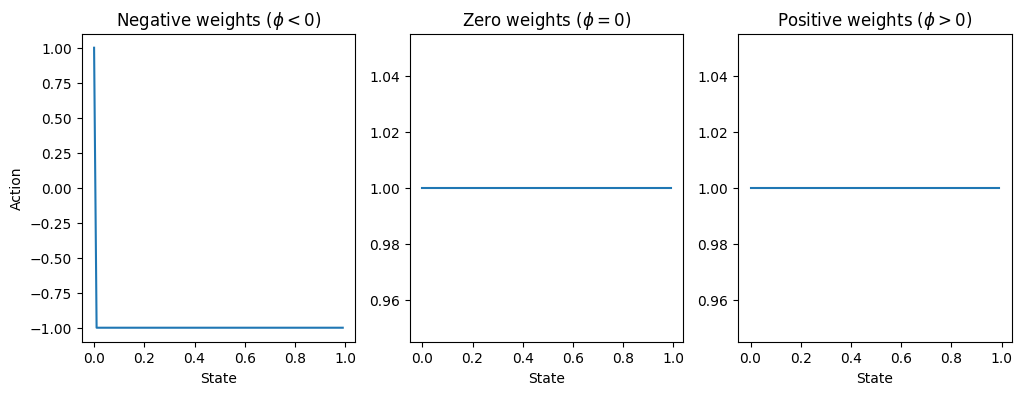

In [5]:
# Create a figure
states = jnp.arange(0, 1, 0.01)
plt.figure(figsize=(12, 4))

# negative phi
actions = [greedy_action(s, -0.01) for s in states]
plt.subplot(1, 3, 1)
plt.xlabel('State')
plt.ylabel('Action')
plt.title(r'Negative weights ($\phi < 0$)')
plt.plot(states, actions)


# zero phi
actions = [greedy_action(s, 0.0) for s in states]
plt.subplot(1, 3, 2)
plt.xlabel('State')
plt.title(r'Zero weights ($\phi = 0$)')
plt.plot(states, actions)

# positive phi
actions = [greedy_action(s, 0.01) for s in states]
plt.subplot(1, 3, 3)
plt.xlabel('State')
plt.title(r'Positive weights ($\phi > 0$)')
plt.plot(states, actions)

plt.show()

In [21]:
# parameters
num_episodes = 1000
gamma = 0.9
alpha = 0.1
key_init = jax.random.PRNGKey(0)

In [22]:
def scan_step_fn(state, unused_t):
    w, epsilon, env_state = state
    obs, _, key = env_state
    key, action_key, next_action_key = jax.random.split(key, 3)

    action = greedy_action(obs, w)
    action = epsilon_greedy_action(action_key, action, epsilon)

    env_state, timestep = step_fn(env_state, action)
    next_obs, reward, done = timestep

    # get next action
    next_action = greedy_action(next_obs, w)
    next_action = epsilon_greedy_action(next_action_key, next_action, epsilon)

    # construct TD target
    target = gamma * q_hat(next_obs, next_action, w) * (1-done) + reward

    l = loss(obs, action, w, target)
    w = w + alpha*grad_loss(obs, action, w, target)
    return (w, epsilon, env_state), (w, l)

def scan_episode_fn(state, unused_t):
    key, w, count = state
    key, reset_key = jax.random.split(key)
    initial_env_state, _ = reset_fn(reset_key)
    epsilon = exponential_decay(count)

    initial_state = (w, epsilon, initial_env_state)
    (w, _, _), (w_hist, loss_hist) = jax.lax.scan(scan_step_fn, initial_state, jnp.arange(max_steps))
    return (key, w, count+1), (w_hist, loss_hist)

def sarsa(key, w):
    initial_state = (key, w, 1)
    (_, w, _), (w_hist, loss_hist) = jax.lax.scan(scan_episode_fn, initial_state, jnp.arange(num_episodes))
    return w, w_hist, loss_hist

sarsa_fn = jax.jit(sarsa)

In [23]:
key, subkey = jax.random.split(key_init)
w_init = jax.random.normal(subkey)
w_init

Array(-2.4424558, dtype=float32)

In [24]:
w_updated, w_hist, loss_hist = sarsa_fn(key_init, w_init)
w_updated

Array(0.00108844, dtype=float32)

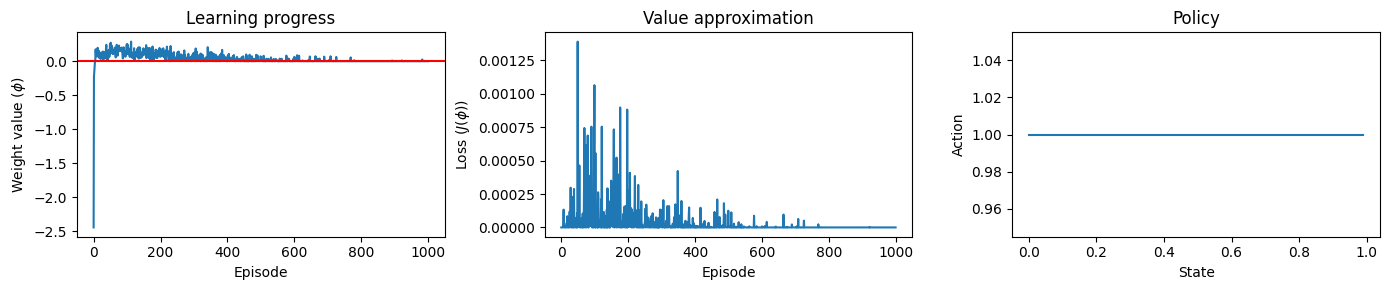

In [25]:
plt.figure(figsize=(14, 3))

plt.subplot(1, 3, 1)
plt.xlabel('Episode')
plt.ylabel(r'Weight value ($\phi$)')
plt.title('Learning progress')
plt.plot(w_hist.ravel()[::max_steps])
plt.axhline(y=0, color='r', linestyle='-')

plt.subplot(1, 3, 2)
plt.xlabel('Episode')
plt.ylabel(r'Loss ($J(\phi)$)')
plt.title('Value approximation')
plt.plot(loss_hist.ravel()[::max_steps])

actions = [greedy_action(s, w_updated) for s in states]
plt.subplot(1, 3, 3)
plt.xlabel('State')
plt.ylabel('Action')
plt.title('Policy')
plt.plot(states, actions)

plt.tight_layout()
plt.show()

In [26]:
def linear_policy(obs, key):
    return greedy_action(obs, w_updated)

env_states = animation_rollout(linear_policy, key)
env.animate(env_states)

## **Off-policy learning with *experience replay***

### **$Q$-learning** with a *replay buffer*

Let $D = ∅$ be a *replay buffer*, then

**Repeat**:
- Collect *experience* consisting of tuples $( S_t, A_t, R_{t+1}, S_{t+1} )$, and add these to the
replay buffer
  - $D = D \cup \{ ( S_0, A_0, R_1, S_1 ), ( S_1, A_1, R_2, S_2 ), \ldots, ( S_{T-1}, A_{T-1}, R_T, S_T ) \}$
- Find parameter vector $\phi$ minimising over a sampled batch from the replay buffer:

$$
L(\phi) = \mathbb{E}_{(S, A, R, S^\prime) \sim D} \left[ \left( R + \gamma \max_{a} \hat{q}_\phi(S^\prime, a) - \hat{q}_\phi(S, A) \right)^2 \right]
$$




In [27]:
def scan_rollout_step_fn(state, unused_t):
    w, env_state, epsilon = state
    obs, _, key = env_state[0]
    key, subkey = jax.random.split(key)
    action = greedy_action(obs, w)
    action = epsilon_greedy_action(subkey, action, epsilon)
    env_state = step_fn(env_state[0], action)
    append = (obs, action, env_state[1][1], env_state[1][0])
    return (w, env_state, epsilon), (append)

def rollout_episode_fn(key, w, epsilon):
    reset_key, policy_key = jax.random.split(key)
    env_state = reset_fn(reset_key)
    initial_state = (w, env_state, epsilon)

    (_, _, _), (trajectory) = jax.lax.scan(scan_rollout_step_fn, initial_state, jnp.arange(max_steps))

    return jnp.array(trajectory)

batched_rollout_fn = jax.vmap(rollout_episode_fn, in_axes=(0, None, None))

In [28]:
num_episodes = 10
keys = jax.random.split(jax.random.PRNGKey(0), num_episodes)
trajectories = batched_rollout_fn(keys, w_init, 1).transpose(0, 2, 1).reshape((-1, 4))
trajectories.shape

(500, 4)

In [29]:
# hyperparameters
buffer_size = 10000
batch_size = 100
num_episodes = 100
num_updates = 100
gamma = 0.9
alpha = 0.1

# Create an empty buffer
replay_buffer = jnp.zeros((buffer_size, 4))
mask = jnp.ones((num_episodes*max_steps,), dtype=jnp.int32)

In [30]:
def scan_batch_update_fn(state, unused_t):
    key, w, epsilon, replay_buffer, index, mask = state
    key, rollout_key, sample_key = jax.random.split(key, 3)
    rollout_keys = jax.random.split(rollout_key, num_episodes)

    # gather experience
    experience = batched_rollout_fn(rollout_keys, w, epsilon).transpose(0, 2, 1).reshape((-1, 4))
    experience = experience[mask]

    # add to the buffer
    replay_buffer = jax.lax.dynamic_update_slice(replay_buffer, experience, (index, 0))

    # randomly sample experience
    indices = jax.random.choice(sample_key, buffer_size, shape=(batch_size,), replace=False)
    sampled_experience = replay_buffer[indices]
    obs, actions, rewards, next_obs = sampled_experience[0], sampled_experience[1], sampled_experience[2], sampled_experience[3]

    # compute max q
    greedy_actions = greedy_action(obs, w)
    max_qs = jnp.array([jnp.max(jnp.array([q_hat(o, 1, w), q_hat(o, -1, w)])) for o in obs])

    # construct TD target
    targets = gamma * max_qs + rewards

    # update
    l = jnp.sum(loss(obs, actions, w, targets))
    w = w + alpha*jnp.mean(grad_loss(obs, actions, w, targets))

    # compute mask
    new_index = (index + experience.shape[0]) % buffer_size
    mask = (experience[:, 0] > 0 & (experience[:, 0] == experience[:, 3]) & (experience[:, 2] == 0)).astype(jnp.int32)

    return (key, w, epsilon, replay_buffer, new_index, mask), (w, l)

def q_learning(key, w):
    initial_state = (key, w, 0.5, replay_buffer, 0, mask)
    (_, w, _, _, _, _), (w_hist, loss_hist) = jax.lax.scan(scan_batch_update_fn, initial_state, jnp.arange(num_updates))
    return w, w_hist, loss_hist

q_learning_fn = jax.jit(q_learning)

In [31]:
w_init

Array(-2.4424558, dtype=float32)

In [32]:
w_updated, w_hist, loss_hist = q_learning_fn(key_init, w_init)
w_updated

Array(0.5170536, dtype=float32)

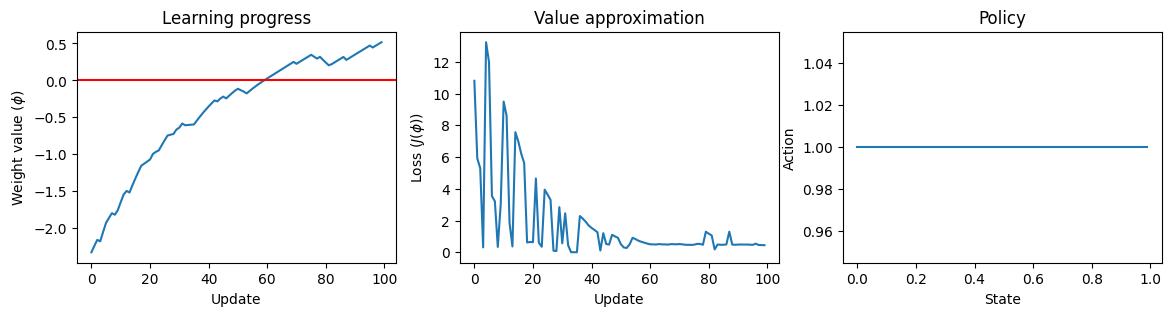

In [33]:
plt.figure(figsize=(14, 3))

plt.subplot(1, 3, 1)
plt.xlabel('Update')
plt.ylabel(r'Weight value ($\phi$)')
plt.title('Learning progress')
plt.plot(w_hist)
plt.axhline(y=0, color='r', linestyle='-')

plt.subplot(1, 3, 2)
plt.xlabel('Update')
plt.ylabel(r'Loss ($J(\phi)$)')
plt.title('Value approximation')
plt.plot(loss_hist)

actions = [greedy_action(s, w_updated) for s in states]
plt.subplot(1, 3, 3)
plt.xlabel('State')
plt.ylabel('Action')
plt.title('Policy')
plt.plot(states, actions)

plt.show()